# Mối tương quan của SPX và VIX 

1. Tải dữ liệu 

- SPX  daily return 

- VIX daily 

2. Tính toán thông số

$$R_{\text{log}, t} = \ln \left( \frac{P_t}{P_{t-1}} \right) = \ln(P_t) - \ln(P_{t-1})$$

$$\Delta VIX_t = VIX_t - VIX_{t-1}$$

3. Tính correlation theo window_size mong muốn

$$r = \frac{\sum (X_i - \bar{X})(Y_i - \bar{Y})}{\sqrt{\sum (X_i - \bar{X})^2} \cdot \sqrt{\sum (Y_i - \bar{Y})^2}}$$

4. Trực quan 

## Step by Step 

In [2]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [3]:
start_date = '2015-01-01'
window_size = 252

In [4]:
data = yf.download(['^GSPC', '^VIX'], start=start_date, auto_adjust = False)

[*********************100%***********************]  2 of 2 completed


In [5]:
close_data = data['Close'].copy()
close_data.columns = ['SPX_Close', 'VIX_Close']
close_data.dropna(inplace=True)
close_data

,SPX_Close,VIX_Close
Date,,
2015-01-02,2058.199951,17.790001
2015-01-05,2020.579956,19.920000
2015-01-06,2002.609985,21.120001
2015-01-07,2025.900024,19.309999
2015-01-08,2062.139893,17.010000
...,...,...
2025-12-10,6886.680176,15.770000
2025-12-11,6901.000000,14.850000
2025-12-15,6816.509766,16.500000


In [6]:
close_data['SPX_Return'] = np.log(close_data['SPX_Close']).diff()
close_data['VIX_Change'] = close_data['VIX_Close'].diff()
close_data.dropna(inplace=True)

In [7]:
close_data['Rolling_Corr'] = close_data['SPX_Return'].rolling(window=window_size).corr(close_data['VIX_Change'])
final_data = close_data.dropna(subset=['Rolling_Corr'])

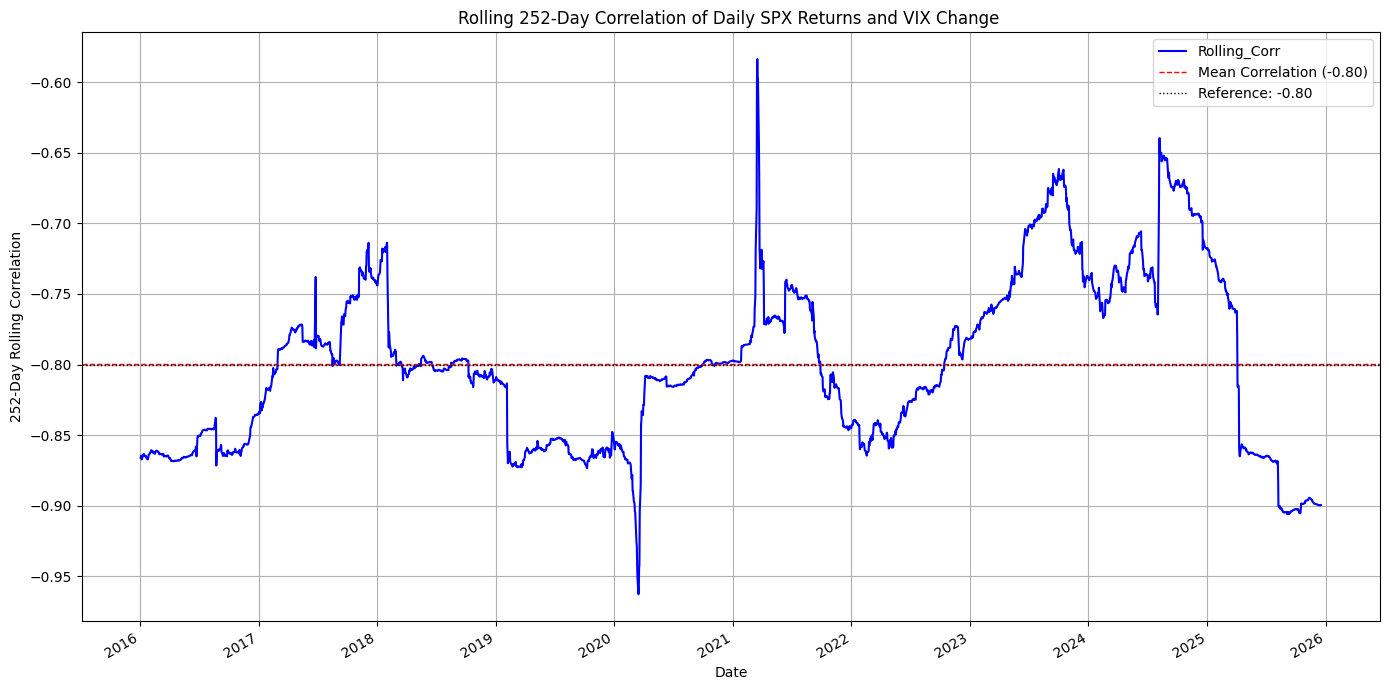

In [8]:
plt.figure(figsize=(14, 7))
final_data['Rolling_Corr'].plot(
        title=f'Rolling {window_size}-Day Correlation of Daily SPX Returns and VIX Change ',
        ylabel=f'{window_size}-Day Rolling Correlation',
        xlabel='Date',
        grid=True,
        color='blue'
    )
mean_corr = final_data['Rolling_Corr'].mean()
plt.axhline(mean_corr, color='r', linestyle='--', linewidth=1, label=f'Mean Correlation ({mean_corr:.2f})')
plt.axhline(-0.8, color='k', linestyle=':', linewidth=1, label='Reference: -0.80')

plt.legend()
plt.tight_layout()

## Function 

In [9]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

def calculate_and_plot_spx_vix_correlation(window_size=252, start_date='1990-01-01'):
    """
    Tải dữ liệu SPX và VIX, xử lý cấu trúc MultiIndex,
    tính toán và vẽ đồ thị mối tương quan luân phiên.
    """
    print(f"--- Bắt đầu tính toán mối tương quan luân phiên {window_size} ngày ---")

    # 1. Tải dữ liệu 
    try:
        data = yf.download(['^GSPC', '^VIX'], start=start_date, progress=False, auto_adjust=False)
    except Exception as e:
        print(f"Lỗi khi tải dữ liệu từ yfinance: {e}")
        return
    if data.empty:
        print("Không thể tải dữ liệu SPX hoặc VIX.")
        return

    # Lấy giá close và loại bỏ cấu trúc multiple index 
    close_data = data['Close'].copy()
    
    # Đổi tên cột và xử lý NaN
    close_data.columns = ['SPX_Close', 'VIX_Close']
    close_data.dropna(inplace=True) 

    # 2. Tính toán số liệu 
    close_data['SPX_Return'] = np.log(close_data['SPX_Close']).diff()

    close_data['VIX_Change'] = close_data['VIX_Close'].diff()

    # Loại bỏ na -> ngày đầu tiên 
    close_data.dropna(inplace=True)
    
    # 3. Tính toán Tương quan Luân phiên
    close_data['Rolling_Corr'] = close_data['SPX_Return'].rolling(window=window_size).corr(close_data['VIX_Change'])

    # Bỏ window_size -1 ngày đầu tiên 
    final_data = close_data.dropna(subset=['Rolling_Corr'])

    # 5. Trực quan hóa 
    plt.figure(figsize=(14, 7))
    final_data['Rolling_Corr'].plot(
        title=f'Rolling {window_size}-Day Correlation of Daily SPX Returns and VIX Change ',
        ylabel=f'{window_size}-Day Rolling Correlation',
        xlabel='Date',
        grid=True,
        color='blue'
    )

    mean_corr = final_data['Rolling_Corr'].mean()
    plt.axhline(mean_corr, color='r', linestyle='--', linewidth=1, label=f'Mean Correlation ({mean_corr:.2f})')
    # Chỉ số lựa chọn xem xét : 
    plt.axhline(-0.8, color='k', linestyle=':', linewidth=1, label='Reference: -0.80')

    plt.legend()
    plt.tight_layout()
    print("----------------------------------------------------------------")

## Result

--- Bắt đầu tính toán mối tương quan luân phiên 252 ngày ---
----------------------------------------------------------------


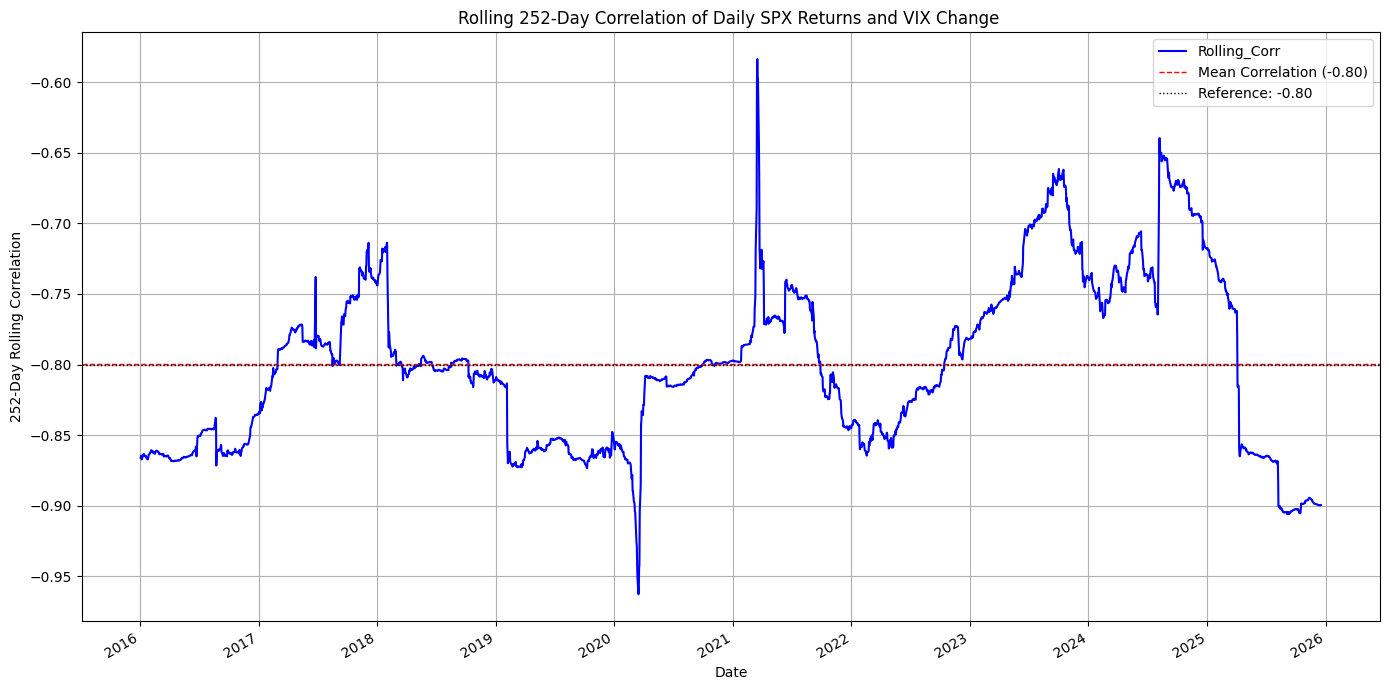

In [10]:
calculate_and_plot_spx_vix_correlation(window_size= 252, start_date = '2015-01-01')

--- Bắt đầu tính toán mối tương quan luân phiên 50 ngày ---
----------------------------------------------------------------


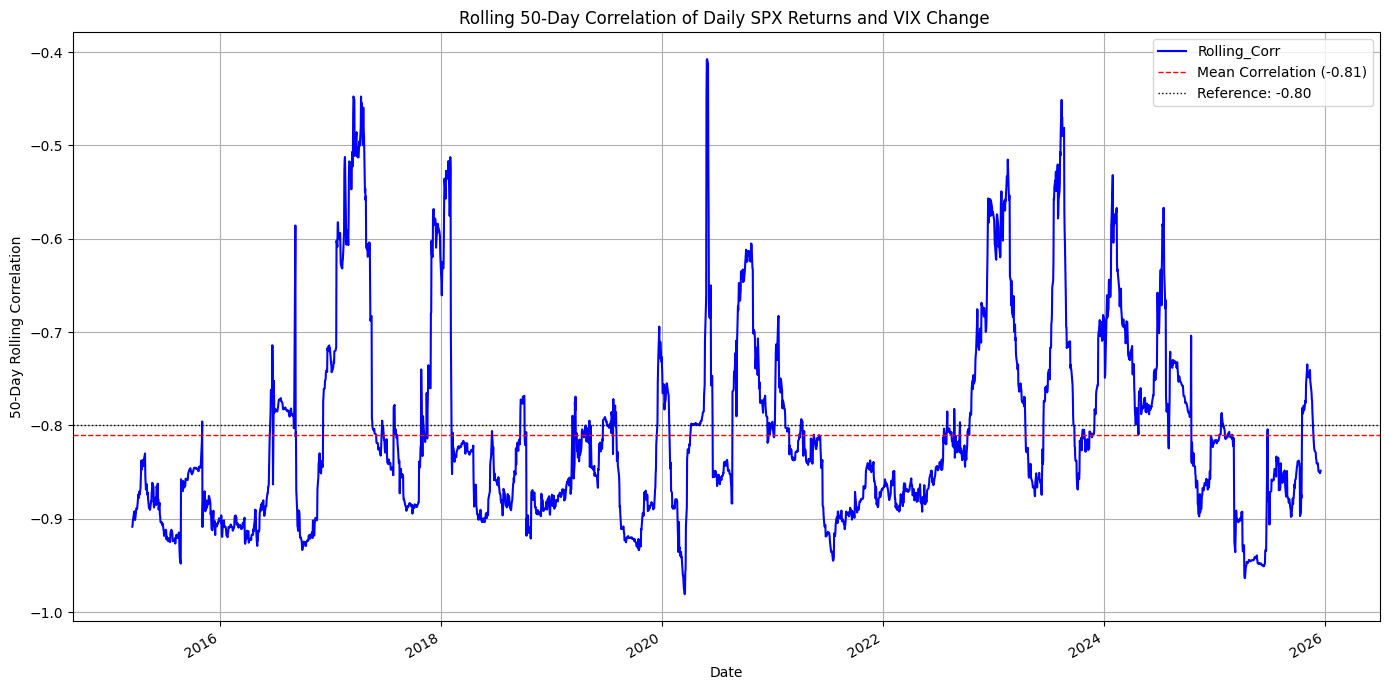

In [11]:
calculate_and_plot_spx_vix_correlation(window_size= 50, start_date = '2015-01-01')

--- Bắt đầu tính toán mối tương quan luân phiên 20 ngày ---
----------------------------------------------------------------


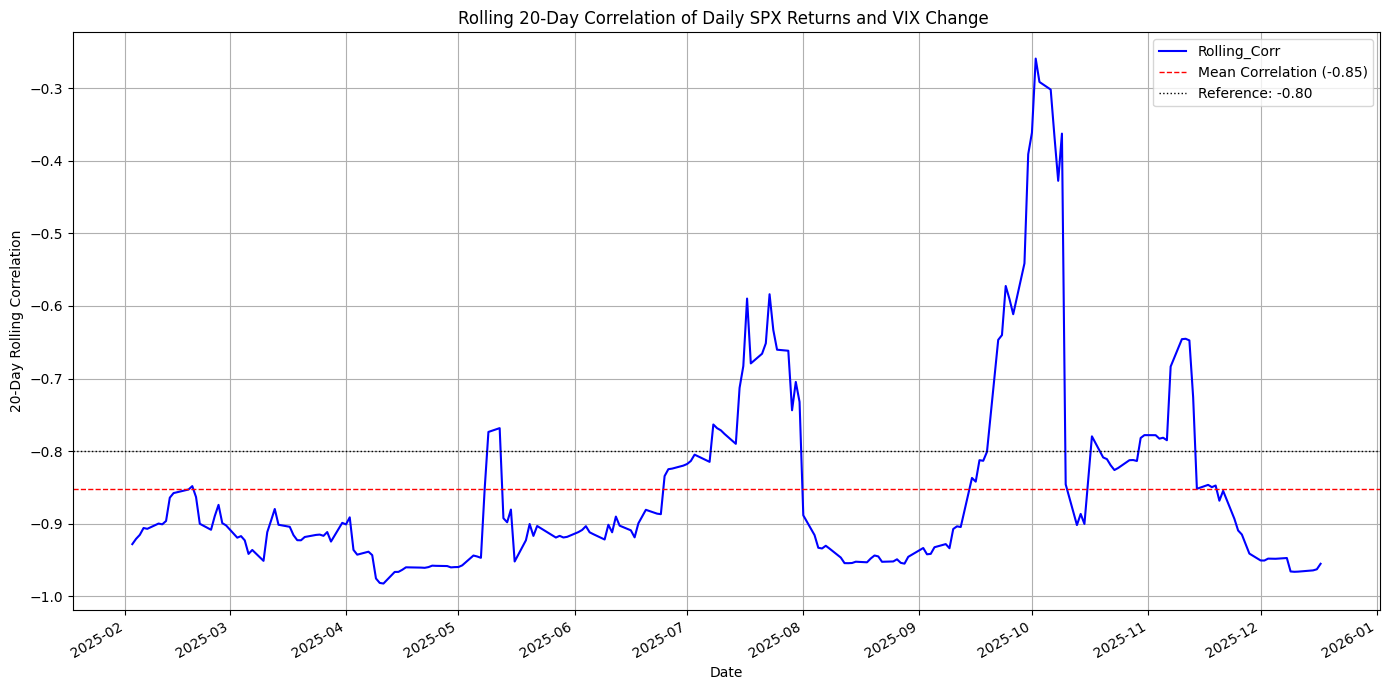

In [12]:
calculate_and_plot_spx_vix_correlation(window_size= 20, start_date = '2025-01-01')